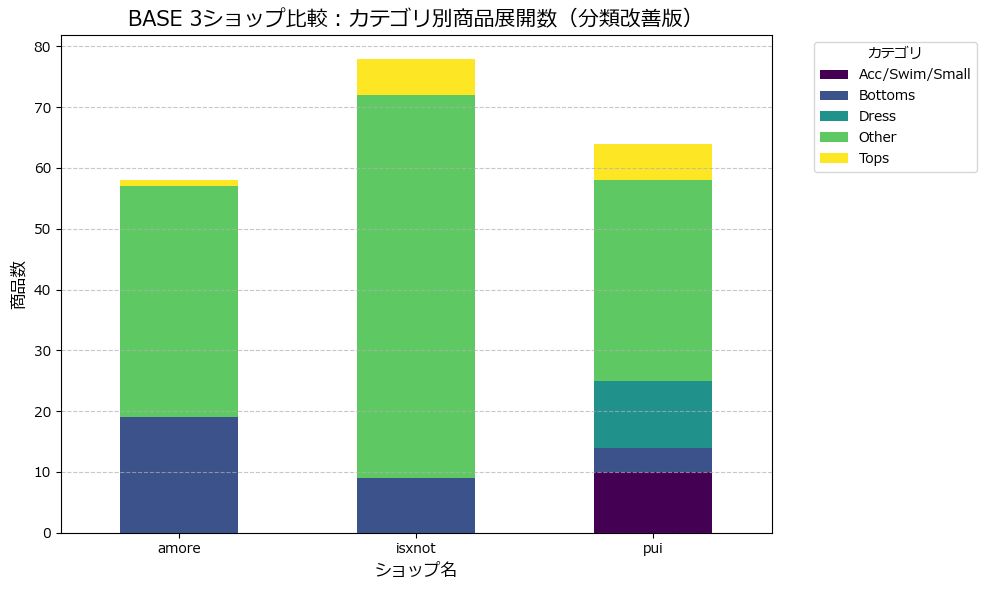

▼ Otherに分類された商品リスト（一部）
['RIBBON KNIT', 'flower peplum one piece', 'gingham peplum one piece', 'rose peplum one-piece', 'Heart peplum one piece', 'lace camisole', 'PUI HOME ROMPERS', 'THE ROSE BALM', 'VINTAGE FLOWER POUCH SET', 'TRENCH COAT']


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. データの読み込み
df = pd.read_csv("combined_base_data.csv")

# 2. 最強の判定ロジック（Otherを激減させる）
def infer_category(name):
    name = str(name).lower()
    # トップス
    if any(k in name for k in ['top', 'tee', 'tシャツ', 'シャツ', 'ブラウス', 'blouse', 'tops', 'ニット', 'カーディガン']):
        return 'Tops'
    # ワンピース
    if any(k in name for k in ['dress', 'onepiece', 'ワンピース', 'ドレス']):
        return 'Dress'
    # ボトムス（デニムやレギンスを追加）
    if any(k in name for k in ['pants', 'skirt', 'bottoms', 'パンツ', 'スカート', 'denim', 'ジーンズ', 'レギンス']):
        return 'Bottoms'
    # 小物・水着（swimやsocksをここに集約）
    if any(k in name for k in ['bag', 'accessories', 'ピアス', 'ネックレス', 'バッグ', 'swim', '水着', 'socks', '靴下']):
        return 'Acc/Swim/Small'
    
    # どれにも当てはまらないものが Other
    return 'Other'

df['Category'] = df['商品名'].apply(infer_category)

# 3. 集計（ショップごと、カテゴリごとの件数）
cat_counts = df.groupby(['ショップ名', 'Category']).size().unstack(fill_value=0)

# 4. グラフの描画
plt.rcParams['font.family'] = 'Meiryo' # Windowsの日本語文字化け対策
cat_counts.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='viridis')

plt.title("BASE 3ショップ比較：カテゴリ別商品展開数（分類改善版）", fontsize=15)
plt.xlabel("ショップ名", fontsize=12)
plt.ylabel("商品数", fontsize=12)
plt.legend(title="カテゴリ", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# おまけ：Otherに分類されてしまった商品の名前を少し見てみる
print("▼ Otherに分類された商品リスト（一部）")
print(df[df['Category'] == 'Other']['商品名'].head(10).tolist())